In [1]:
#import library 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path.cwd().parents[2]

DATA_PATH = ROOT_DIR / "data" / "primary" / "final_dataset_modeling.csv"

print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

c:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\final_dataset_modeling.csv


In [3]:
#data understanding 
df.info()

df.describe()

df["komoditas"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kabupaten        364 non-null    str    
 1   tahun            364 non-null    int64  
 2   produktivitas    364 non-null    float64
 3   komoditas        364 non-null    str    
 4   temperature      364 non-null    float64
 5   temp_max         364 non-null    float64
 6   temp_min         364 non-null    float64
 7   rainfall         364 non-null    float64
 8   humidity         364 non-null    float64
 9   wind_speed       364 non-null    float64
 10  solar_radiation  364 non-null    float64
dtypes: float64(8), int64(1), str(2)
memory usage: 36.3 KB


komoditas
Padi        126
Singkong    121
Jagung      117
Name: count, dtype: int64

In [4]:
#one hot encoding 
df_encoded = pd.get_dummies(
    df,
    columns=["komoditas"],
    dtype=int
)

In [5]:
#feature selection 
features = [
    "temperature",
    "temp_max",
    "temp_min",
    "rainfall",
    "humidity",
    "wind_speed",
    "solar_radiation",
    "komoditas_Jagung",
    "komoditas_Padi",
    "komoditas_Singkong"
]

X = df_encoded[features]

y = df_encoded["produktivitas"]

In [6]:
#train test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
#random forest baseline 
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [8]:
#evaluation 
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 25.59
RMSE : 46.02
R²   : 0.7883


In [10]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Hitung permutation importance
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# DataFrame importance
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance,std
9,komoditas_Singkong,83.563010,8.638655
8,komoditas_Padi,0.063345,0.038515
7,komoditas_Jagung,0.024200,0.038735
0,temperature,-0.017286,1.934237
5,wind_speed,-0.440070,0.904194
1,temp_max,-0.679914,0.672290
3,rainfall,-1.243096,1.221704
2,temp_min,-2.031443,2.150259
6,solar_radiation,-2.061172,0.910323
4,humidity,-2.236633,1.457286


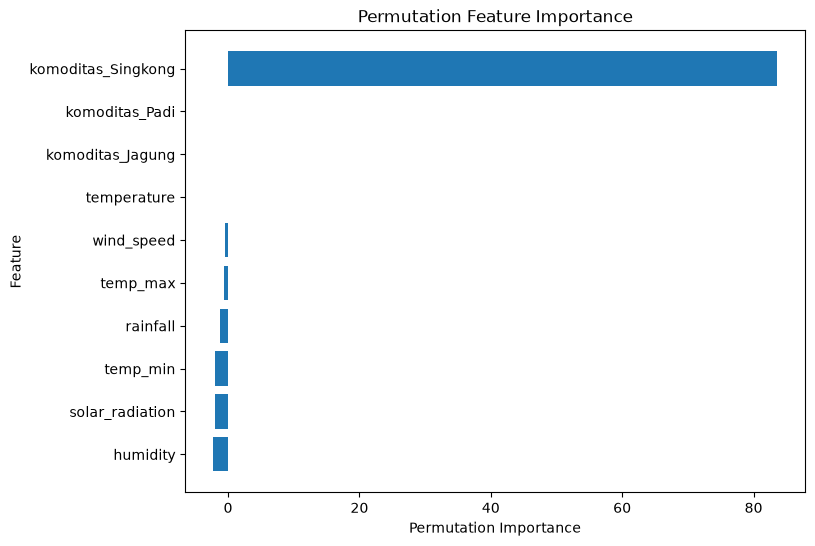

In [11]:
#visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [12]:
df.groupby("komoditas")["produktivitas"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
komoditas,,,,,
Jagung,117,64.118376,15.656740,1.00,89.58
Padi,126,59.820952,5.852174,47.35,77.01
Singkong,121,238.939256,78.508964,1.00,485.24


In [13]:
#xgboost 
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
#evaluasi xgboost
y_pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 26.49
RMSE : 44.93
R²   : 0.7983


In [15]:
#shuffle x cross validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.79827108 0.77800585 0.82135703 0.71916046 0.72103574]
0.7675660318253449


In [17]:
#xgboost
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance,std
9,komoditas_Singkong,83.756199,8.934395
0,temperature,3.217494,3.058123
3,rainfall,0.400895,1.422305
1,temp_max,0.224310,0.684673
2,temp_min,0.176533,2.056561
7,komoditas_Jagung,0.066532,0.066042
8,komoditas_Padi,0.012635,0.011287
4,humidity,-0.217596,1.845400
5,wind_speed,-0.426883,0.381289
6,solar_radiation,-0.657615,0.963526


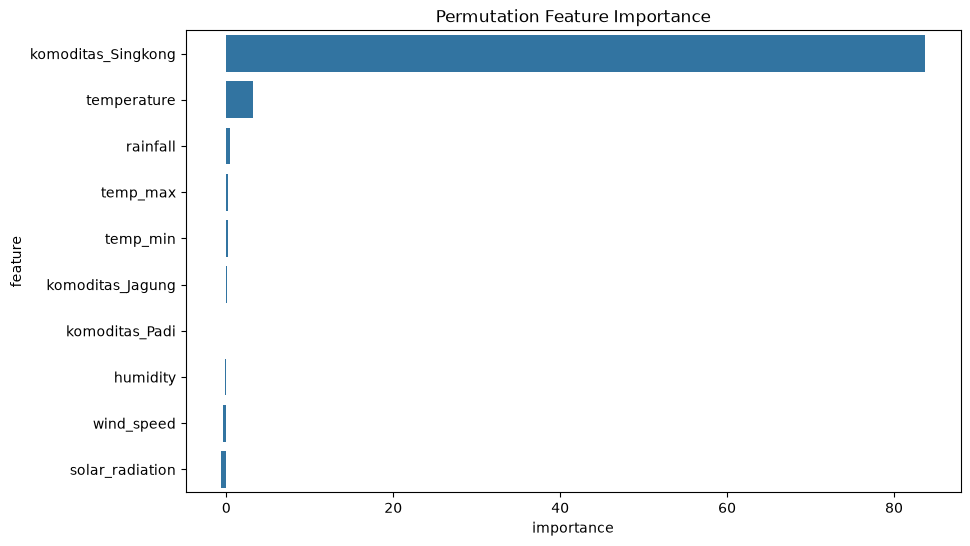

In [19]:
#evaluasi xgboost
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="importance",
    y="feature"
)

plt.title("Permutation Feature Importance")
plt.show()

Hasil:
Model terbaik: XGBoost Regressor
R² Score: 0,798
Rata-rata R² Cross Validation (5-Fold): 0,768
Faktor yang paling berpengaruh terhadap produktivitas adalah jenis komoditas, suhu minimum, dan radiasi matahari.

In [22]:
#simpan model
from pathlib import Path
import joblib

ROOT_DIR = Path.cwd().parents[2]

MODEL_DIR = ROOT_DIR / "models" / "yield_prediction"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    xgb,
    MODEL_DIR / "yield_prediction_xgb.pkl"
)

print("Model berhasil disimpan di:")
print(MODEL_DIR / "yield_prediction_xgb.pkl")

Model berhasil disimpan di:
c:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\models\yield_prediction\yield_prediction_xgb.pkl
